In [48]:
# Imports
import json
import math
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

try:
    import seaborn as sns  # type: ignore
except Exception:
    sns = None

In [49]:
# Configuration (fast, test-only)
PROJECT_ROOT = Path('.').resolve()
MODELS_DIR = PROJECT_ROOT / 'models'
DATA_DIR = PROJECT_ROOT / 'data'
TEST_DIR = DATA_DIR / 'asl_alphabet_test' / 'asl_alphabet_test'

# Use all images (29)
MAX_IMAGES: int | None = None
BATCH_SIZE = 128

labels = {
    'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9,
    'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18,
    'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28,
}
id_to_label = {v: k for k, v in labels.items()}
class_names = [id_to_label[i] for i in range(len(id_to_label))]

MODEL_PATHS: dict[str, Path] = {}
if MODELS_DIR.exists():
    for p in sorted(MODELS_DIR.glob('*.h5')):
        MODEL_PATHS[p.stem] = p

print('Models found:')
for k, p in MODEL_PATHS.items():
    print(f'  - {k}: {p} (exists={p.exists()})')
print('Test dir:', TEST_DIR)
print('Max images:', MAX_IMAGES)

Models found:
  - efficientnet: G:\project ai\models\efficientnet.h5 (exists=True)
  - inception: G:\project ai\models\inception.h5 (exists=True)
  - resnet: G:\project ai\models\resnet.h5 (exists=True)
Test dir: G:\project ai\data\asl_alphabet_test\asl_alphabet_test
Max images: None


In [50]:
# Dataset helpers
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def get_model_image_size(model: tf.keras.Model) -> tuple[int, int]:
    shape = model.input_shape
    if isinstance(shape, list):
        shape = shape[0]
    if not shape or len(shape) < 4:
        return (224, 224)
    h, w = shape[1], shape[2]
    if h is None or w is None:
        return (224, 224)
    return (int(h), int(w))

def preprocess_for_model(images: tf.Tensor, model_key: str) -> tf.Tensor:
    images = tf.cast(images, tf.float32)
    key = model_key.lower()
    if 'efficientnet' in key:
        from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
        return eff_pre(images)
    return images / 255.0

def make_dataset(eval_dir: Path, image_size: tuple[int, int], batch_size: int) -> tuple[tf.data.Dataset, list[str]]:
    # If directory has class subfolders, use the standard loader
    subdirs = [p for p in eval_dir.iterdir() if p.is_dir()]
    if subdirs:
        ds_raw = tf.keras.utils.image_dataset_from_directory(
            eval_dir,
            labels='inferred',
            label_mode='int',
            color_mode='rgb',
            batch_size=batch_size,
            image_size=image_size,
            shuffle=False,
        )
        class_names_out = list(ds_raw.class_names)
        ds = ds_raw.prefetch(tf.data.AUTOTUNE)
        return ds, class_names_out

    # Flat directory: infer labels from filename prefix before '_'
    files = [p for p in eval_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
    if not files:
        raise ValueError(f"No images found in directory {eval_dir}")

    def label_from_name(path_str: str) -> int:
        stem = Path(path_str).stem
        prefix = stem.split('_')[0]
        if prefix not in labels:
            raise ValueError(f"Cannot infer label from filename: {path_str}")
        return labels[prefix]

    file_strs = [str(p) for p in sorted(files)]
    label_ints = [label_from_name(p) for p in file_strs]

    path_ds = tf.data.Dataset.from_tensor_slices(file_strs)
    label_ds = tf.data.Dataset.from_tensor_slices(label_ints)

    def load_and_resize(path: tf.Tensor) -> tf.Tensor:
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, image_size)
        return img

    ds_raw = tf.data.Dataset.zip((path_ds, label_ds)).map(
        lambda p, l: (load_and_resize(p), l), num_parallel_calls=tf.data.AUTOTUNE
    )
    ds_raw = ds_raw.batch(batch_size)
    ds = ds_raw.prefetch(tf.data.AUTOTUNE)
    # Use predefined class_names order
    class_names_out = class_names
    return ds, class_names_out

def dataset_with_preprocess(ds: tf.data.Dataset, model_key: str) -> tf.data.Dataset:
    return ds.map(lambda x, y: (preprocess_for_model(x, model_key), y), num_parallel_calls=tf.data.AUTOTUNE)

def collect_labels(ds: tf.data.Dataset) -> np.ndarray:
    ys = []
    for _, y in ds:
        ys.append(y.numpy())
    return np.concatenate(ys, axis=0).astype(int)


Model: efficientnet (efficientnet.h5)
Metric error: Found input variables with inconsistent numbers of samples: [28, 250880]
y_true unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 27 28]
y_pred unique: [0 1 2 3 4 5 6]

Model: inception (inception.h5)
{'accuracy': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0}


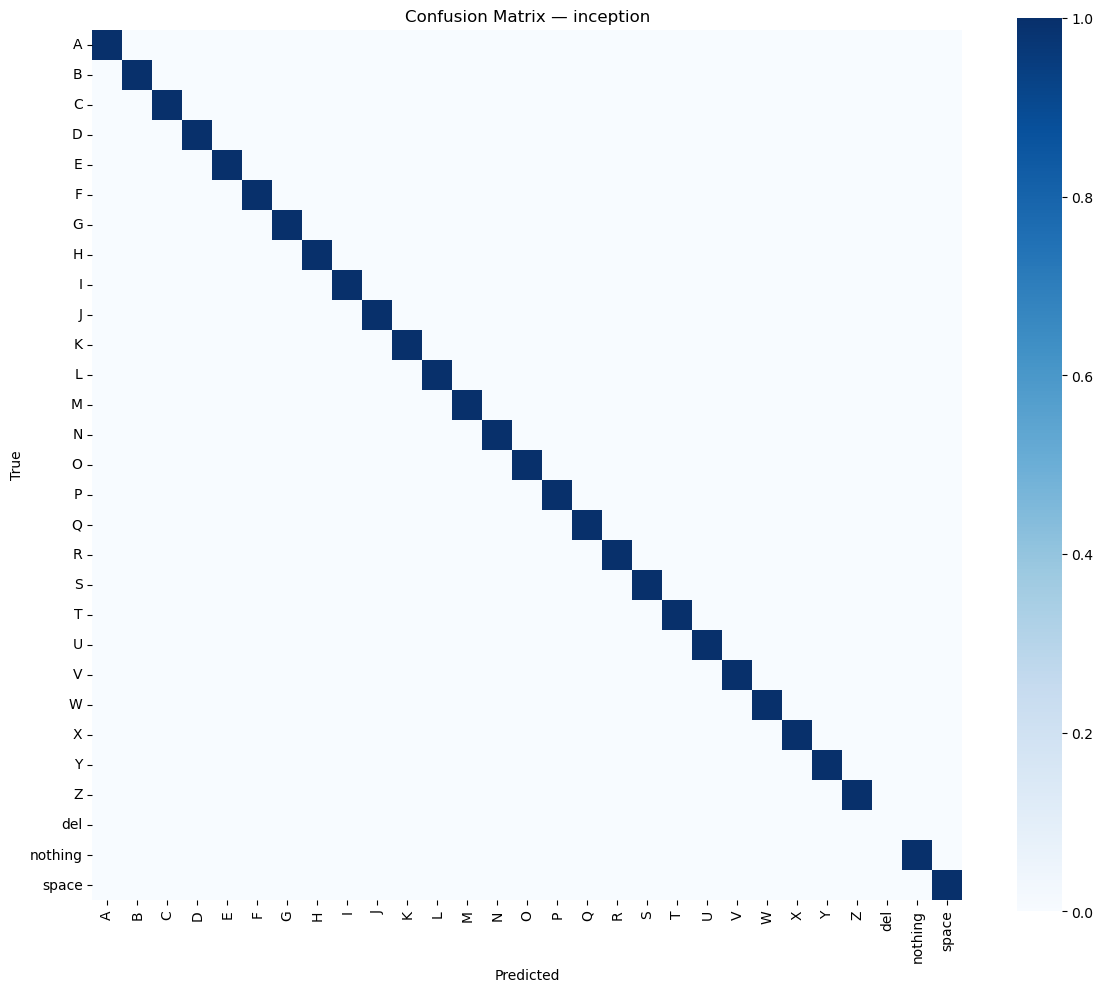


Model: resnet (resnet.h5)
{'accuracy': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0}


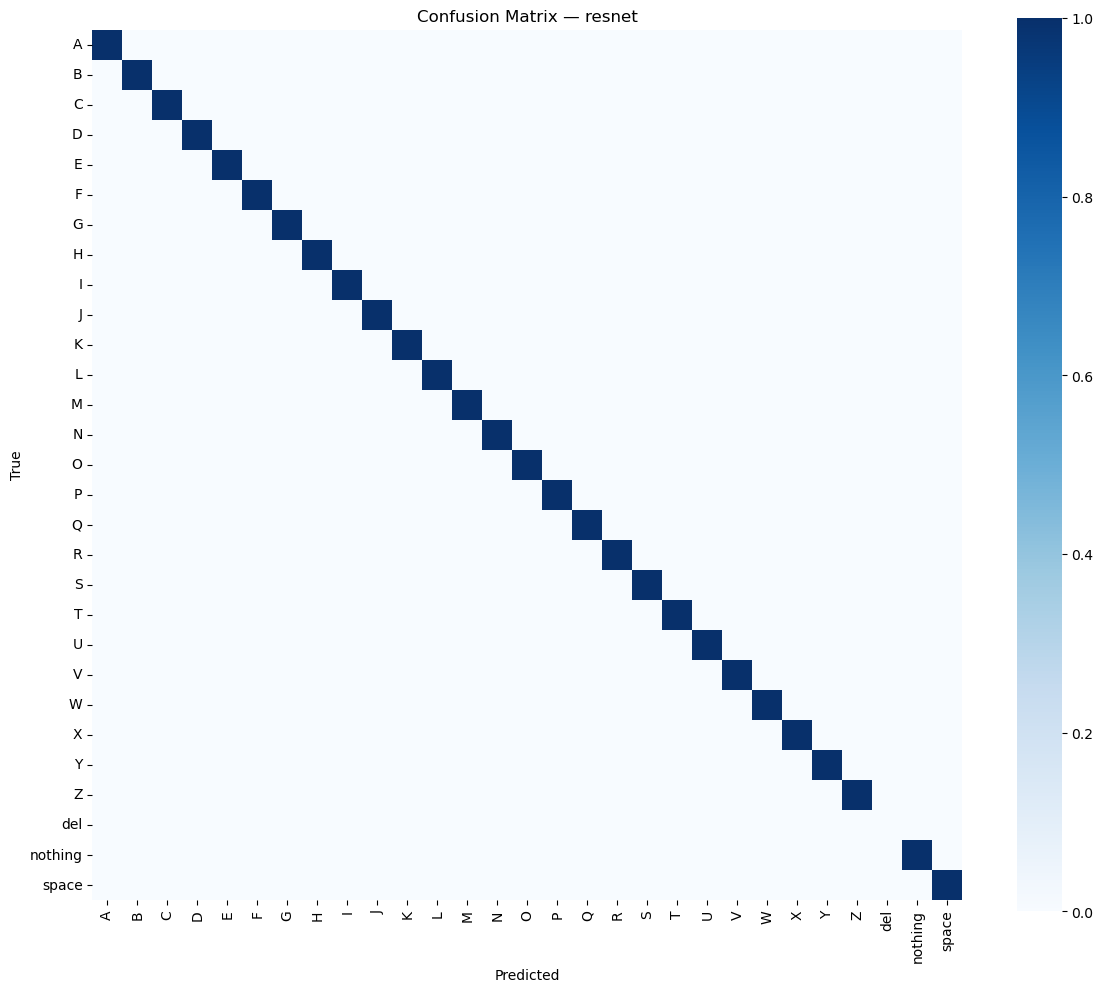

,model,accuracy,precision_macro,recall_macro,n_samples
0,inception,1.0,1.0,1.0,28
1,resnet,1.0,1.0,1.0,28


In [51]:
# Evaluation on asl_alphabet_test (no training)
results_df = pd.DataFrame()

if not TEST_DIR.exists():
    print(f'Missing test dir: {TEST_DIR}')
elif not MODEL_PATHS:
    print(f'No .h5 models found under {MODELS_DIR}')
else:
    results = []
    for model_key, model_path in MODEL_PATHS.items():
        if not model_path.exists():
            print(f'Skipping {model_key}: missing file {model_path}')
            continue
        print('\n' + '=' * 80)
        print(f'Model: {model_key} ({model_path.name})')
        model = load_model(model_path, compile=False)
        image_size = get_model_image_size(model)

        base_ds, ds_class_names = make_dataset(TEST_DIR, image_size=image_size, batch_size=BATCH_SIZE)
        if MAX_IMAGES is not None:
            max_batches = math.ceil(MAX_IMAGES / BATCH_SIZE)
            base_ds = base_ds.take(max_batches)
            print(f'Using first {MAX_IMAGES} images (~{max_batches} batches)')

        y_true = collect_labels(base_ds)
        ds = dataset_with_preprocess(base_ds, model_key)
        y_pred_probs = model.predict(ds, verbose=0)
        if isinstance(y_pred_probs, (list, tuple)):
            y_pred_probs = y_pred_probs[0]
        y_pred_probs = np.asarray(y_pred_probs)
        if y_pred_probs.ndim == 1:
            y_pred = (y_pred_probs >= 0.5).astype(int)
        elif y_pred_probs.ndim == 2 and y_pred_probs.shape[1] == 1:
            y_pred = (y_pred_probs[:, 0] >= 0.5).astype(int)
        else:
            y_pred = np.argmax(y_pred_probs, axis=1).astype(int)

        y_true = np.asarray(y_true, dtype=int).ravel()
        y_pred = np.asarray(y_pred, dtype=int).ravel()

        try:
            acc = float(accuracy_score(y_true, y_pred))
            prec = float(precision_score(y_true, y_pred, average='macro', zero_division=0))
            rec = float(recall_score(y_true, y_pred, average='macro', zero_division=0))
        except ValueError as e:
            print('Metric error:', e)
            print('y_true unique:', np.unique(y_true))
            print('y_pred unique:', np.unique(y_pred))
            continue
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ds_class_names))))

        print({'accuracy': acc, 'precision_macro': prec, 'recall_macro': rec})
        results.append({
            'model': model_key,
            'accuracy': acc,
            'precision_macro': prec,
            'recall_macro': rec,
            'n_samples': int(len(y_true)),
        })

        plt.figure(figsize=(12, 10))
        if sns is not None:
            sns.heatmap(cm, cmap='Blues', square=True, xticklabels=ds_class_names, yticklabels=ds_class_names)
        else:
            plt.imshow(cm, cmap='Blues')
            plt.colorbar()
            plt.xticks(range(len(ds_class_names)), ds_class_names, rotation=90)
            plt.yticks(range(len(ds_class_names)), ds_class_names)
        plt.title(f'Confusion Matrix — {model_key}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.show()

    results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
results_df

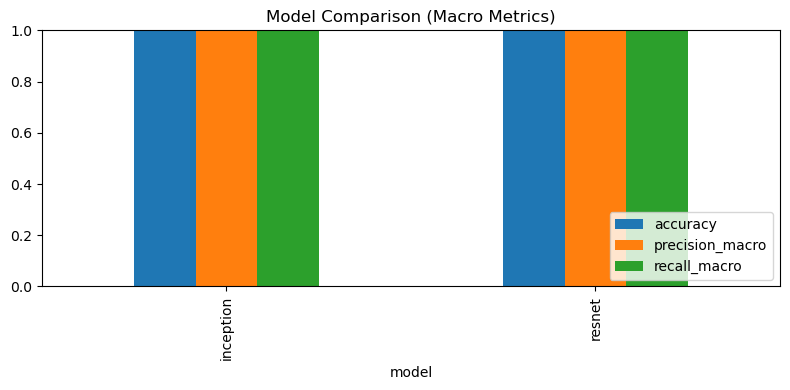

In [52]:
# Comparison plot
if 'results_df' not in globals() or results_df is None or results_df.empty:
    print('No results to compare yet.')
else:
    ax = results_df.set_index('model')[['accuracy', 'precision_macro', 'recall_macro']].plot(kind='bar', figsize=(8, 4))
    ax.set_title('Model Comparison (Macro Metrics)')
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()